# Comparison: UMAP package vs ScanPy implementation

The data consist of *3k PBMCs from a Healthy Donor* and are freely available from 10x Genomics ([here](http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz) from this [webpage](https://support.10xgenomics.com/single-cell-gene-expression/datasets/1.1.0/pbmc3k)). On a unix system, you can uncomment and run the following to download and unpack the data. The last line creates a directory for writing processed data.

In [71]:
# !mkdir data
# !wget http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz -O data/pbmc3k_filtered_gene_bc_matrices.tar.gz
# !cd data; tar -xzf pbmc3k_filtered_gene_bc_matrices.tar.gz
# !mkdir write

In [72]:
import pandas as pd
import scanpy as sc
import numpy as np

In [73]:
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor="white")

scanpy==1.9.8 anndata==0.10.5.post1 umap==0.5.5 numpy==1.26.4 scipy==1.12.0 pandas==2.2.0 scikit-learn==1.4.1.post1 statsmodels==0.14.1 igraph==0.11.4 pynndescent==0.5.11


In [74]:
adata = sc.read_10x_mtx(
    "/home/chananchidas/Documents/scanpy/data/filtered_gene_bc_matrices/hg19/",  # the directory with the `.mtx` file
    var_names="gene_symbols",  # use gene symbols for the variable names (variables-axis index)
    cache=True,  # write a cache file for faster subsequent reading
)

adata.var_names_make_unique()  # this is unnecessary if using `var_names='gene_ids'` in `sc.read_10x_mtx`

... reading from cache file cache/home-chananchidas-Documents-scanpy-data-filtered_gene_bc_matrices-hg19-matrix.h5ad


/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [75]:
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

## Preprocessing

Basic filtering:

In [76]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# annotate the group of mitochondrial genes as "mt"
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()

filtered out 19024 genes that are detected in less than 3 cells


In [77]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

adata.raw = adata

adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])
sc.pp.scale(adata, max_value=10)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
regressing out ['total_counts', 'pct_counts_mt']
    sparse input is densified and may lead to high memory use


/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]


    finished (0:00:05)


## Principal component analysis

Reduce the dimensionality of the data by running principal component analysis (PCA), which reveals the main axes of variation and denoises the data.

In [78]:
sc.tl.pca(adata, svd_solver="arpack")

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:01)


In [79]:
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

## Computing the neighborhood graph

Let us compute the neighborhood graph of cells using the PCA representation of the data matrix. You might simply use default values here. For the sake of reproducing Seurat's results, let's take the following values.

In [80]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


## Embedding the neighborhood graph

In [81]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:04)


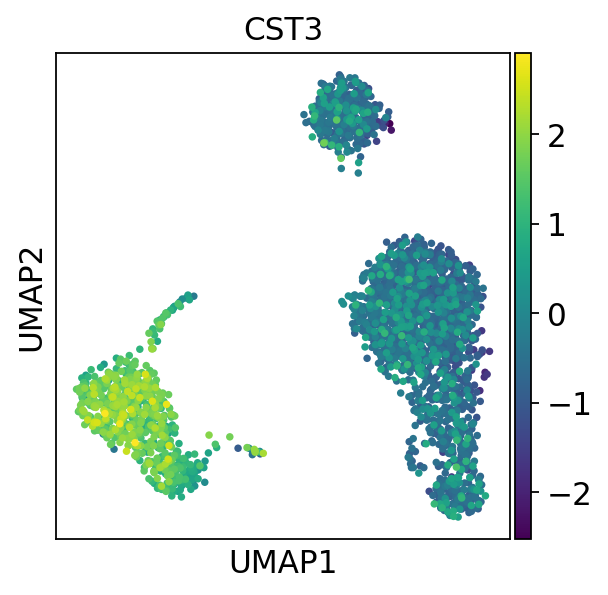

In [82]:
sc.pl.umap(adata, color='CST3', cmap='viridis', use_raw=False)

## Using the original UMAP implementation

The original implementation is somehow slower (8.4 seconds vs the 1.6 + 3.7 seconds of scanpy)

In [83]:
import umap
# Match the umap settings to the scanpy settings
reducer = umap.UMAP(min_dist=0.5, random_state=0, n_neighbors=10)

embedding = reducer.fit_transform(adata.obsm["X_pca"])

/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


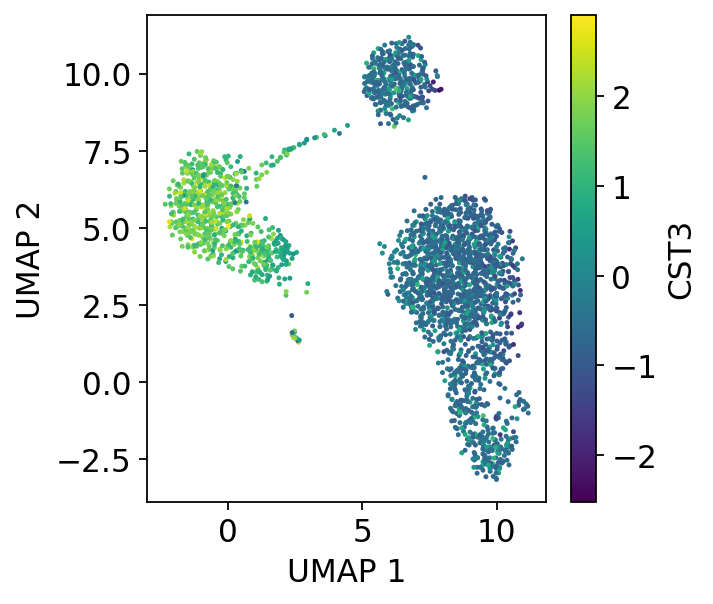

In [84]:
import matplotlib.pyplot as plt

plt.scatter(embedding[:, 0], embedding[:, 1], c=adata.X[:,adata.var_names == "CST3"], cmap='viridis', s=1.5)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.colorbar(label='CST3')
plt.grid(False)
plt.show()


## Leiden clustering

In [85]:
sc.tl.leiden(
    adata,
    resolution=0.9,
    random_state=0,
    n_iterations=2,
    directed=False,
)

running Leiden clustering
    finished: found 8 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


Plot the clusters, which agree quite well with the result of Seurat.

/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


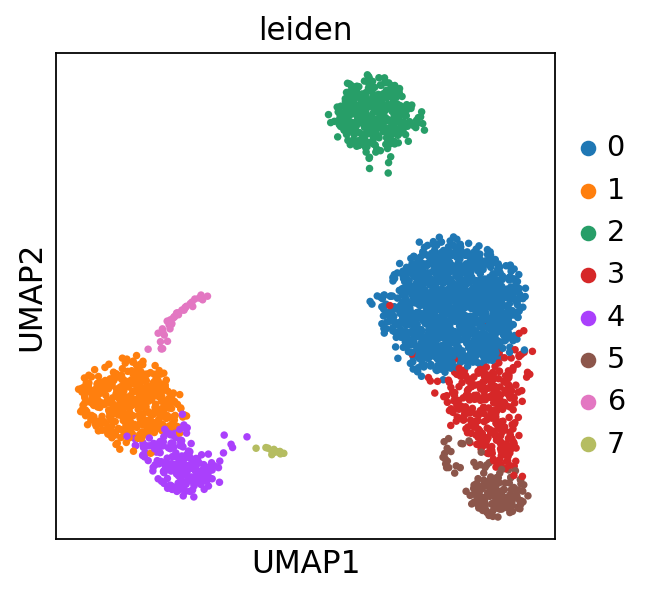

In [86]:
sc.pl.umap(adata, color="leiden")

In [87]:
# Save leiden cluster as list for later use
leiden_clusters = adata.obs['leiden'].tolist()

import matplotlib.patches

levels, categories = pd.factorize(leiden_clusters)
colors = [plt.cm.tab10(i) for i in levels] # using the "tab10" colormap
handles = [matplotlib.patches.Patch(color=plt.cm.tab10(i), label=c) for i, c in enumerate(categories)]

/tmp/ipykernel_6816/66586047.py:6: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  levels, categories = pd.factorize(leiden_clusters)


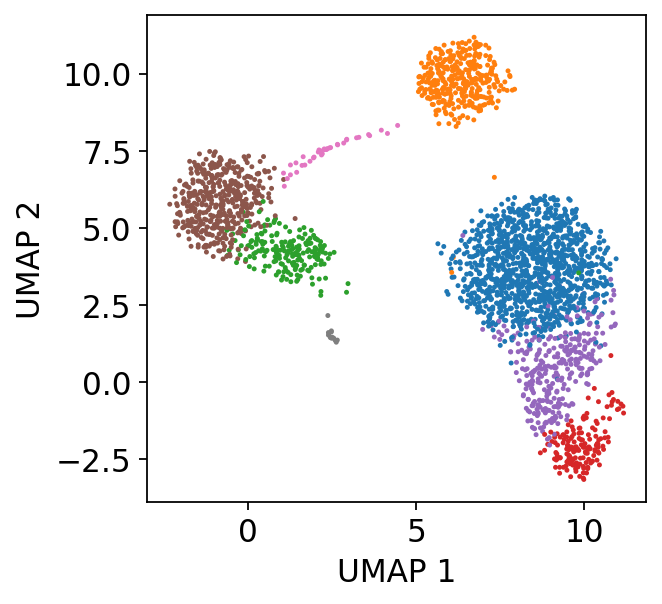

In [88]:
plt.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=1.5)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(False)
plt.show()

## Testing subsampling with parametric UMAP

Here I will subsample 10% to 90% of the data (increments of 10%) and see how well parametric UMAP can recapture the dataset.

In [89]:
from umap.parametric_umap import ParametricUMAP
import random

In [90]:
embeddings = []  # list to store the embeddings

# Loop through different values of frac
for frac in np.arange(0.1, 1.0, 0.1):
    # Subsample adata
    subsampled_indices = random.sample(range(adata.n_obs), int(adata.n_obs * frac))
    adata_subset = adata[subsampled_indices, :]

    # Calculate embedding
    embedder = ParametricUMAP(min_dist=0.5, random_state=0, n_neighbors=10)
    embedder.fit(adata_subset.obsm["X_pca"])
    embedding_all = embedder.transform(adata.obsm["X_pca"])
    embeddings.append(embedding_all)

# Add embeddings to AnnData just in case
for i, embedding in enumerate(embeddings):
    adata.obsm[f"X_umap_frac_{i+1}"] = embedding



2024-03-13 14:21:39.583248: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Epoch 1/10
297/297 [==============================] - 1s 1ms/step - loss: 0.2950
Epoch 2/10
297/297 [==============================] - 0s 2ms/step - loss: 0.2780
Epoch 3/10
297/297 [==============================] - 0s 2ms/step - loss: 0.2769
Epoch 4/10
297/297 [==============================] - 0s 1ms/step - loss: 0.2784
Epoch 5/10
297/297 [==============================] - 0s 2ms/step - loss: 0.2767
Epoch 6/10
297/297 [==============================] - 0s 1ms/step - loss: 0.2765
Epoch 7/10
297/297 [==============================] - 0s 1ms/step - loss: 0.2765
Epoch 8/10
297/297 [==============================] - 0s 1ms/step - loss: 0.2761
Epoch 9/10
297/297 [==============================] - 0s 1ms/step - loss: 0.2781
Epoch 10/10
297/297 [==============================] - 0s 1ms/step - loss: 0.2768


/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Epoch 1/10
304/304 [==============================] - 1s 2ms/step - loss: 0.3028
Epoch 2/10
304/304 [==============================] - 1s 2ms/step - loss: 0.2829
Epoch 3/10
304/304 [==============================] - 1s 2ms/step - loss: 0.2820
Epoch 4/10
304/304 [==============================] - 1s 2ms/step - loss: 0.2811
Epoch 5/10
304/304 [==============================] - 1s 2ms/step - loss: 0.2815
Epoch 6/10
304/304 [==============================] - 1s 2ms/step - loss: 0.2805
Epoch 7/10
304/304 [==============================] - 1s 2ms/step - loss: 0.2807
Epoch 8/10
304/304 [==============================] - 1s 2ms/step - loss: 0.2802
Epoch 9/10
304/304 [==============================] - 1s 2ms/step - loss: 0.2807
Epoch 10/10
304/304 [==============================] - 1s 2ms/step - loss: 0.2803


/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


...

Epoch 1/10
572/572 [==============================] - 2s 3ms/step - loss: 0.2694
Epoch 2/10
572/572 [==============================] - 2s 3ms/step - loss: 0.2545
Epoch 3/10
572/572 [==============================] - 2s 3ms/step - loss: 0.2538
Epoch 4/10
572/572 [==============================] - 2s 3ms/step - loss: 0.2537
Epoch 5/10
572/572 [==============================] - 2s 3ms/step - loss: 0.2538
Epoch 6/10
572/572 [==============================] - 2s 3ms/step - loss: 0.2535
Epoch 7/10
572/572 [==============================] - 2s 3ms/step - loss: 0.2534
Epoch 8/10
572/572 [==============================] - 2s 4ms/step - loss: 0.2532
Epoch 9/10
572/572 [==============================] - 2s 3ms/step - loss: 0.2530
Epoch 10/10
572/572 [==============================] - 2s 4ms/step - loss: 0.2529


/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Epoch 1/10
650/650 [==============================] - 8s 12ms/step - loss: 0.2708
Epoch 2/10
650/650 [==============================] - 5s 8ms/step - loss: 0.2559
Epoch 3/10
650/650 [==============================] - 2s 4ms/step - loss: 0.2553
Epoch 4/10
650/650 [==============================] - 3s 4ms/step - loss: 0.2547
Epoch 5/10
650/650 [==============================] - 2s 4ms/step - loss: 0.2549
Epoch 6/10
650/650 [==============================] - 3s 5ms/step - loss: 0.2544
Epoch 7/10
650/650 [==============================] - 4s 6ms/step - loss: 0.2545
Epoch 8/10
650/650 [==============================] - 4s 6ms/step - loss: 0.2543
Epoch 9/10
650/650 [==============================] - 4s 6ms/step - loss: 0.2544
Epoch 10/10
650/650 [==============================] - 5s 7ms/step - loss: 0.2541


/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Epoch 1/10
735/735 [==============================] - 3s 3ms/step - loss: 0.2710
Epoch 2/10
735/735 [==============================] - 3s 3ms/step - loss: 0.2562
Epoch 3/10
735/735 [==============================] - 2s 3ms/step - loss: 0.2552
Epoch 4/10
735/735 [==============================] - 2s 3ms/step - loss: 0.2547
Epoch 5/10
735/735 [==============================] - 2s 3ms/step - loss: 0.2542
Epoch 6/10
735/735 [==============================] - 2s 3ms/step - loss: 0.2542
Epoch 7/10
735/735 [==============================] - 3s 3ms/step - loss: 0.2543
Epoch 8/10
735/735 [==============================] - 2s 3ms/step - loss: 0.2543
Epoch 9/10
735/735 [==============================] - 3s 4ms/step - loss: 0.2539
Epoch 10/10
735/735 [==============================] - 3s 3ms/step - loss: 0.2540


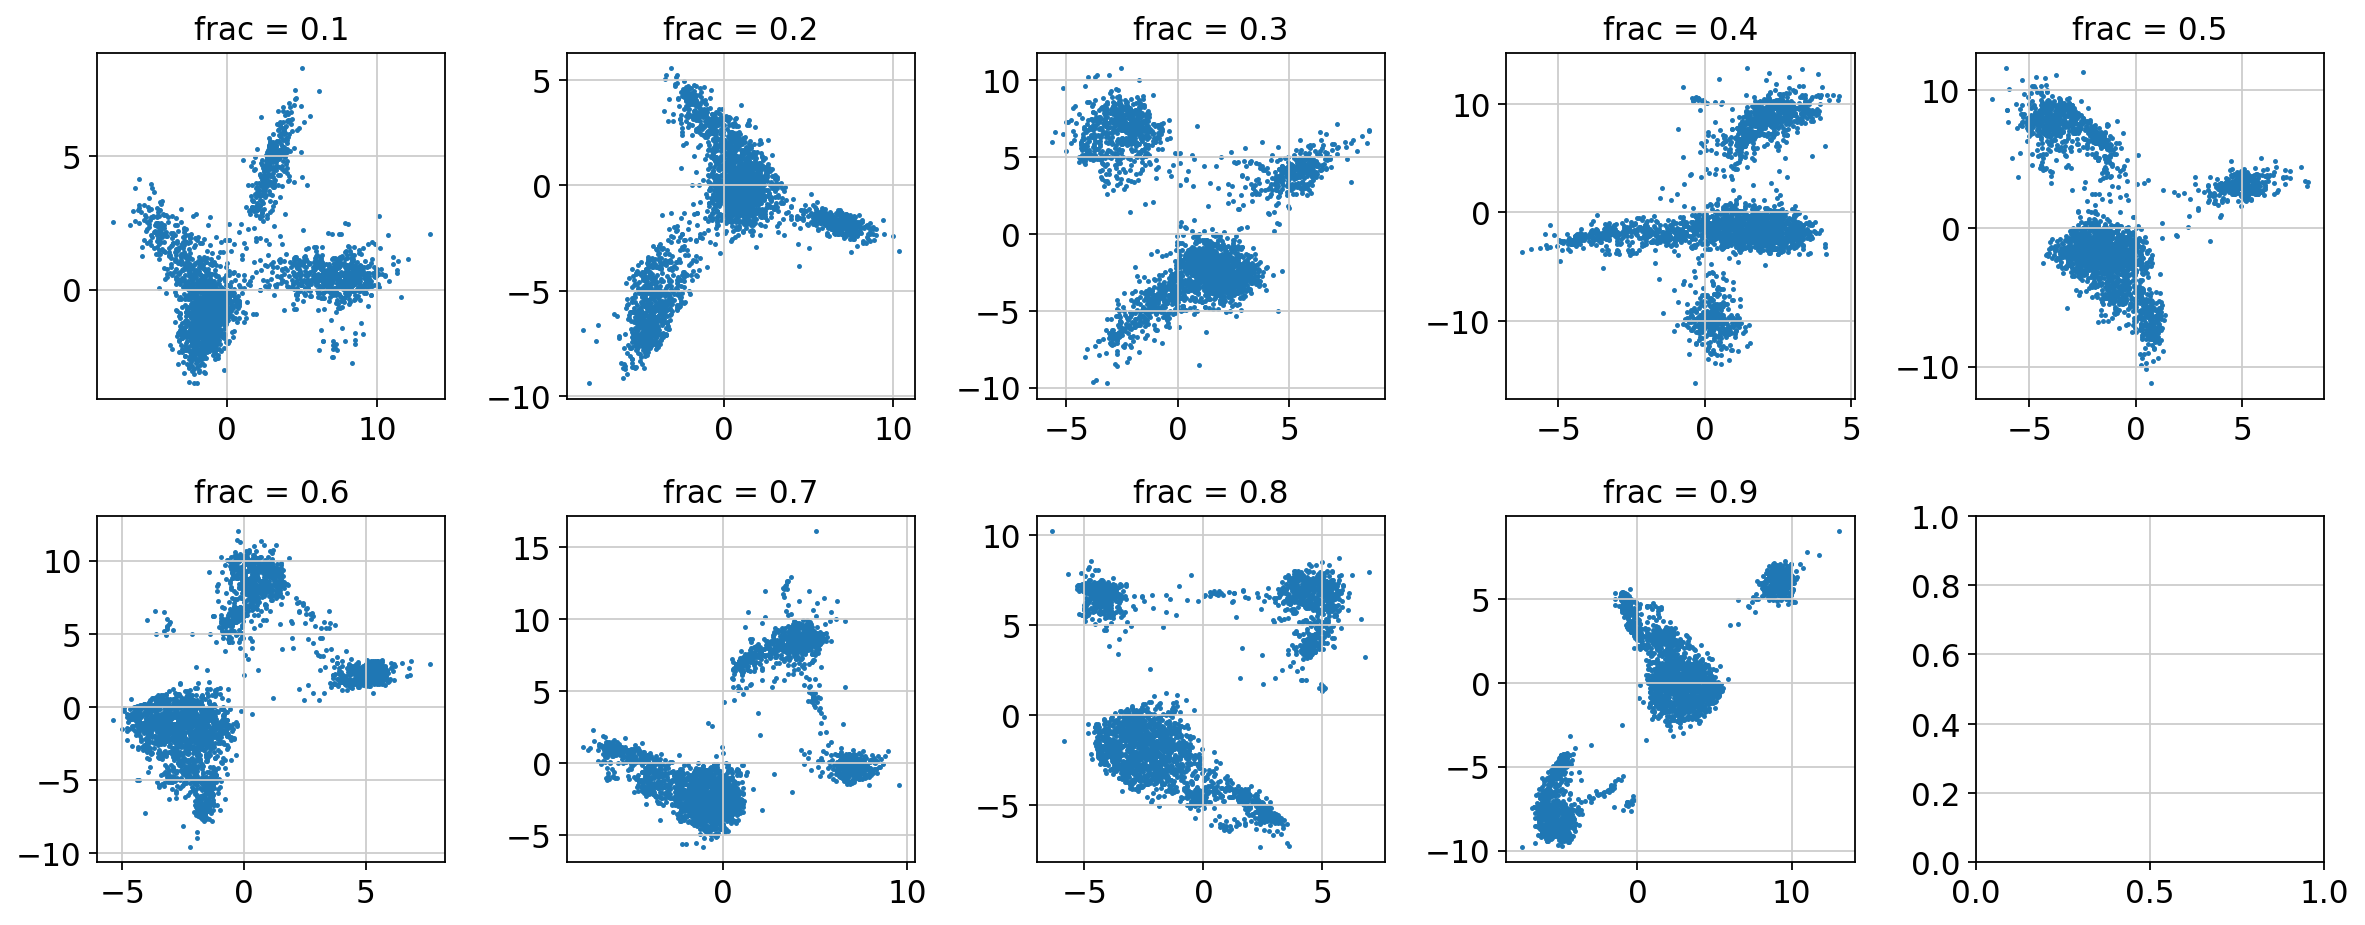

In [91]:
# Plot the embeddings
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, embedding in enumerate(embeddings):
    axes[i].scatter(embedding[:, 0], embedding[:, 1], s=1.5)
    axes[i].set_title("frac = {:.1f}".format(0.1 *(i+1)))

plt.tight_layout()
plt.show()

Now, try to rerun the embeddings with 10% of the data

In [92]:
# Try different samplings using 10% of the data
embeddings = []  # list to store the embeddings
embedders = []

# Loop through different values of frac
for i in range(10):
    frac = 0.1
    
    # Subsample adata
    subsampled_indices = random.sample(range(adata.n_obs), int(adata.n_obs * frac))
    adata_subset = adata[subsampled_indices, :]

    # Fit data
    embedder = ParametricUMAP(min_dist=0.5, random_state=0, n_neighbors=10)
    embedder.fit(adata_subset.obsm["X_pca"])

    # Transform the rest of the dataset
    embedding_all = embedder.transform(adata.obsm["X_pca"])
    embeddings.append(embedding_all)
    embedders.append(embedder)

/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Epoch 1/10
304/304 [==============================] - 1s 2ms/step - loss: 0.3098
Epoch 2/10
304/304 [==============================] - 0s 1ms/step - loss: 0.2944
Epoch 3/10
304/304 [==============================] - 0s 1ms/step - loss: 0.2925
Epoch 4/10
304/304 [==============================] - 0s 1ms/step - loss: 0.2928
Epoch 5/10
304/304 [==============================] - 0s 1ms/step - loss: 0.2916
Epoch 6/10
304/304 [==============================] - 0s 2ms/step - loss: 0.2920
Epoch 7/10
304/304 [==============================] - 0s 2ms/step - loss: 0.2919
Epoch 8/10
304/304 [==============================] - 0s 2ms/step - loss: 0.2923
Epoch 9/10
304/304 [==============================] - 0s 2ms/step - loss: 0.2915
Epoch 10/10
304/304 [==============================] - 0s 2ms/step - loss: 0.2918


/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Epoch 1/10
296/296 [==============================] - 1s 2ms/step - loss: 0.3111
Epoch 2/10
296/296 [==============================] - 0s 2ms/step - loss: 0.2968
Epoch 3/10
296/296 [==============================] - 0s 2ms/step - loss: 0.2954
Epoch 4/10
296/296 [==============================] - 0s 2ms/step - loss: 0.2943
Epoch 5/10
296/296 [==============================] - 1s 2ms/step - loss: 0.2940
Epoch 6/10
296/296 [==============================] - 2s 7ms/step - loss: 0.2935
Epoch 7/10
296/296 [==============================] - 3s 10ms/step - loss: 0.2939
Epoch 8/10
296/296 [==============================] - 2s 6ms/step - loss: 0.2943
Epoch 9/10
296/296 [==============================] - 1s 2ms/step - loss: 0.2943
Epoch 10/10
296/296 [==============================] - 0s 2ms/step - loss: 0.2937


/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


...

Epoch 1/10
296/296 [==============================] - 1s 2ms/step - loss: 0.2959
Epoch 2/10
296/296 [==============================] - 0s 1ms/step - loss: 0.2800
Epoch 3/10
296/296 [==============================] - 0s 1ms/step - loss: 0.2801
Epoch 4/10
296/296 [==============================] - 0s 1ms/step - loss: 0.2794
Epoch 5/10
296/296 [==============================] - 0s 1ms/step - loss: 0.2786
Epoch 6/10
296/296 [==============================] - 1s 2ms/step - loss: 0.2790
Epoch 7/10
296/296 [==============================] - 0s 1ms/step - loss: 0.2774
Epoch 8/10
296/296 [==============================] - 0s 2ms/step - loss: 0.2786
Epoch 9/10
296/296 [==============================] - 0s 2ms/step - loss: 0.2778
Epoch 10/10
296/296 [==============================] - 0s 1ms/step - loss: 0.2776


/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Epoch 1/10
303/303 [==============================] - 1s 1ms/step - loss: 0.3077
Epoch 2/10
303/303 [==============================] - 0s 1ms/step - loss: 0.2947
Epoch 3/10
303/303 [==============================] - 0s 1ms/step - loss: 0.2944
Epoch 4/10
303/303 [==============================] - 0s 1ms/step - loss: 0.2943
Epoch 5/10
303/303 [==============================] - 0s 2ms/step - loss: 0.2937
Epoch 6/10
303/303 [==============================] - 0s 1ms/step - loss: 0.2931
Epoch 7/10
303/303 [==============================] - 0s 1ms/step - loss: 0.2929
Epoch 8/10
303/303 [==============================] - 0s 1ms/step - loss: 0.2938
Epoch 9/10
303/303 [==============================] - 0s 1ms/step - loss: 0.2935
Epoch 10/10
303/303 [==============================] - 0s 1ms/step - loss: 0.2938


/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


Epoch 1/10
298/298 [==============================] - 1s 2ms/step - loss: 0.3053
Epoch 2/10
298/298 [==============================] - 0s 2ms/step - loss: 0.2901
Epoch 3/10
298/298 [==============================] - 0s 1ms/step - loss: 0.2897
Epoch 4/10
298/298 [==============================] - 0s 1ms/step - loss: 0.2889
Epoch 5/10
298/298 [==============================] - 0s 1ms/step - loss: 0.2887
Epoch 6/10
298/298 [==============================] - 0s 1ms/step - loss: 0.2889
Epoch 7/10
298/298 [==============================] - 0s 2ms/step - loss: 0.2884
Epoch 8/10
298/298 [==============================] - 0s 1ms/step - loss: 0.2881
Epoch 9/10
298/298 [==============================] - 0s 1ms/step - loss: 0.2878
Epoch 10/10
298/298 [==============================] - 0s 1ms/step - loss: 0.2878


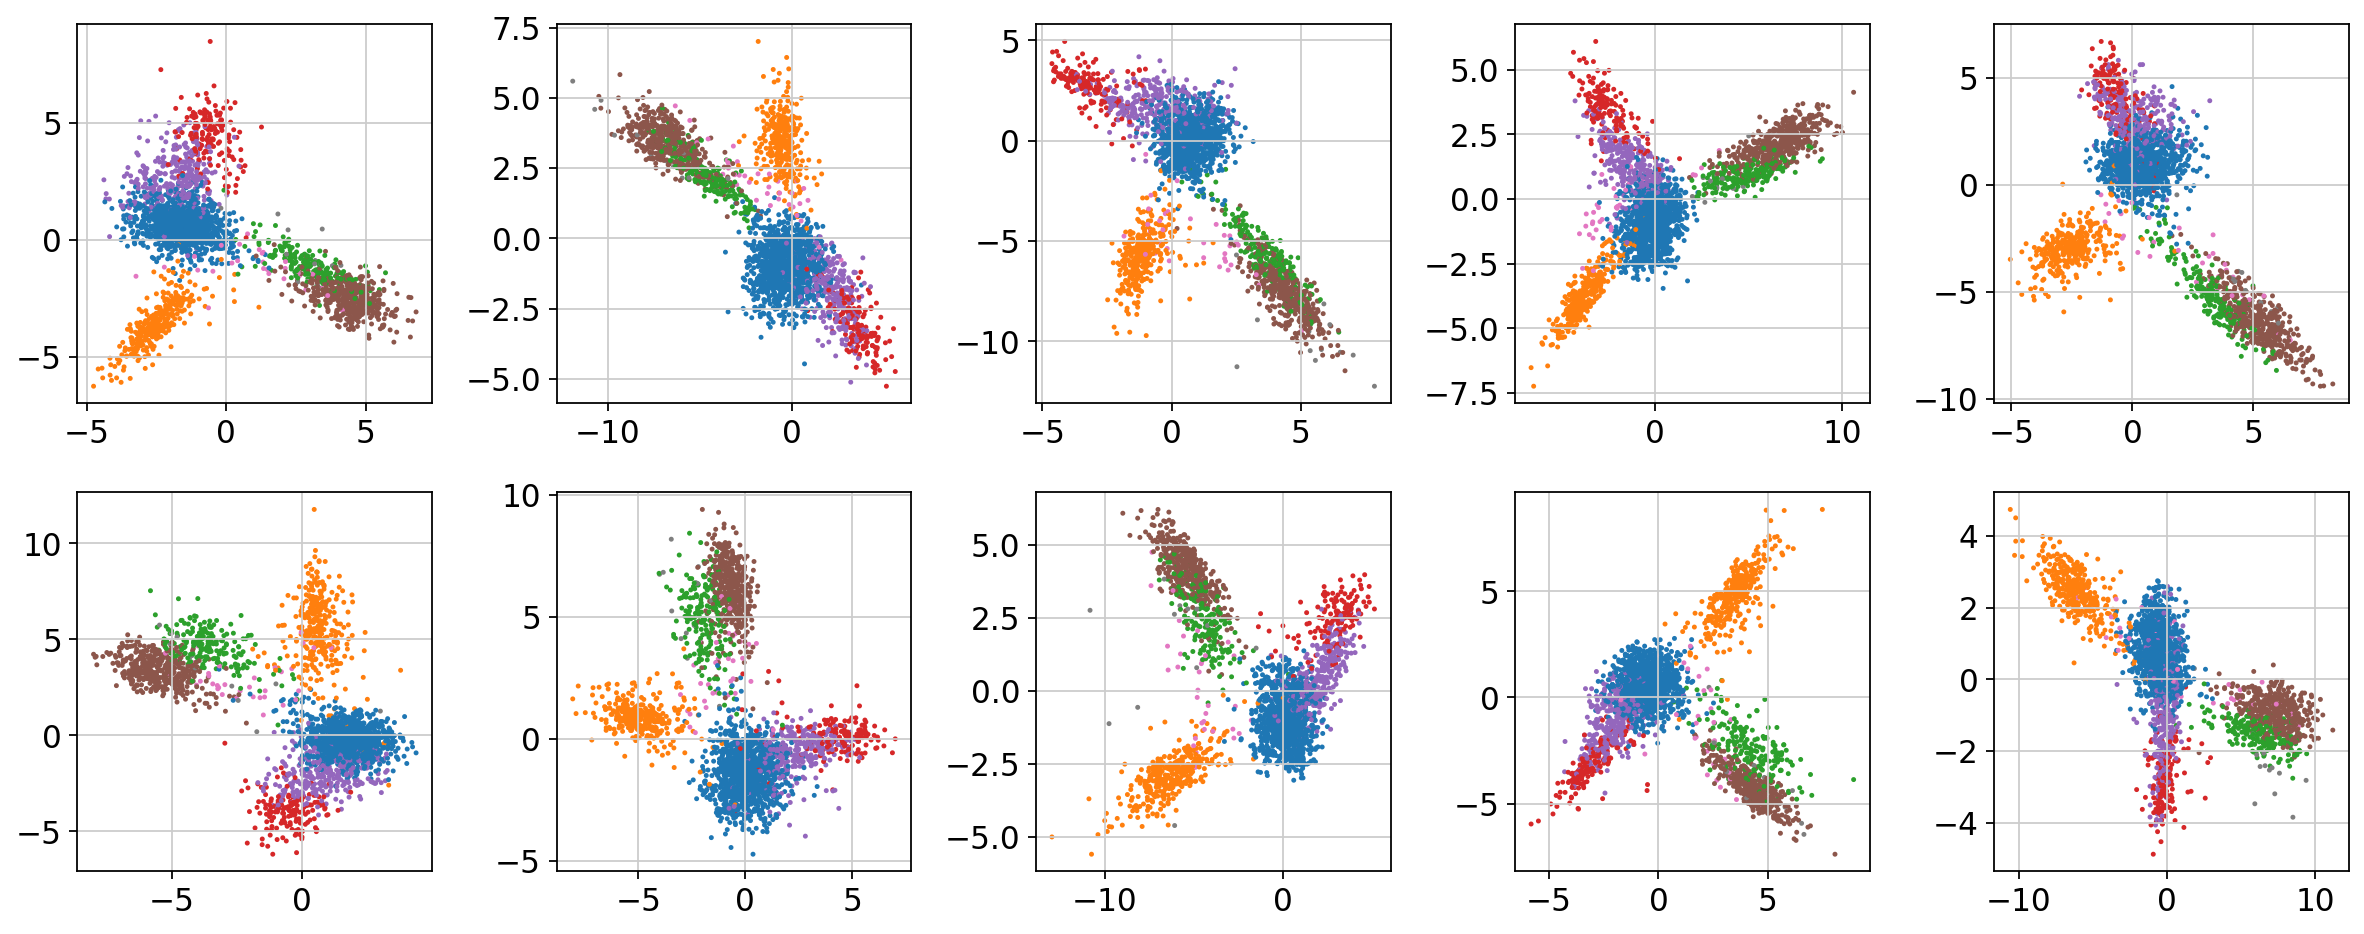

In [93]:
# Plot
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, embedding in enumerate(embeddings):
    # Color with leiden clusters
    axes[i].scatter(embedding[:, 0], embedding[:, 1], c=colors, s=1.5)

    
plt.tight_layout()
plt.show()


## Combining multiple UMAP models (doesn't work)

https://umap-learn.readthedocs.io/en/latest/composing_models.html

In [94]:
# Three ways to do it
all_embedders_union = embedders[0] + embedders[1] + embedders[2] + embedders[3] + embedders[4] + embedders[5] + embedders[6] + embedders[7] + embedders[8] + embedders[9]
all_embedders_intersect = embedders[0] * embedders[1] * embedders[2] * embedders[3] * embedders[4] * embedders[5] * embedders[6] * embedders[7] * embedders[8] * embedders[9]
all_embedders_contrast = embedders[0] - embedders[1] - embedders[2] - embedders[3] - embedders[4] - embedders[5] - embedders[6] - embedders[7] - embedders[8] - embedders[9]

/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/umap/plot.py:449: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(points[:, 0], points[:, 1], s=point_size, c=color)


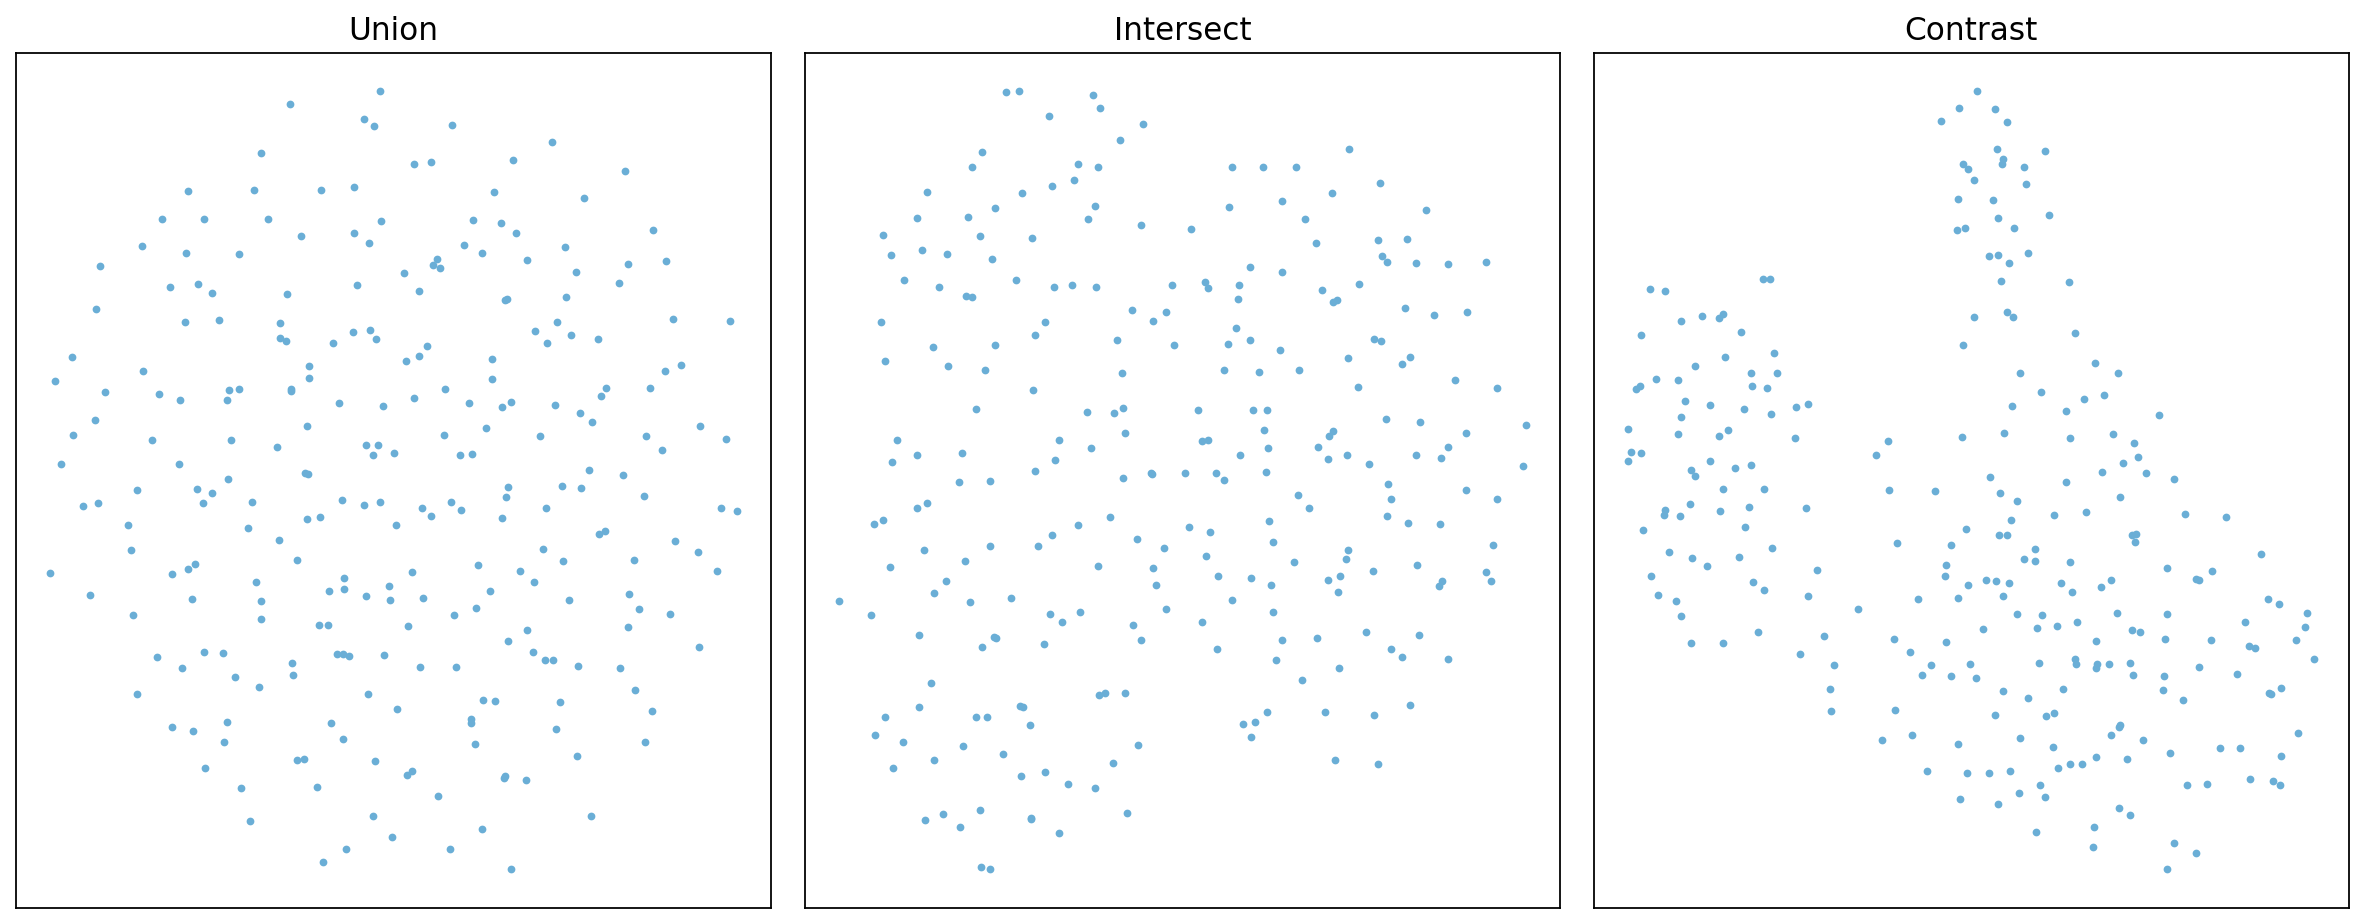

In [105]:
import umap.plot

# Make three plots with umap.plot points, each in its own subplot
# Also add title but remove x and y label
# Remove subtitle
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes = axes.flatten()

umap.plot.points(all_embedders_union, ax=axes[0])
axes[0].texts[0].set_visible(False)
axes[0].set_title("Union")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

umap.plot.points(all_embedders_intersect, ax=axes[1])
axes[1].texts[0].set_visible(False)
axes[1].set_title("Intersect")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

umap.plot.points(all_embedders_contrast, ax=axes[2])
axes[2].texts[0].set_visible(False)
axes[2].set_title("Contrast")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

## Match results of Scanpy's neighbors function

In [106]:
#print(adata.obsp['connectivities'][:5,:5].todense())
print(adata.obsp['connectivities'].shape)
#print(adata.obsp['distances'][:5,:5].todense())
print(adata.obsp['distances'].shape)

(2638, 2638)
(2638, 2638)


### The neighbor function uses PyNNDescentTransformer in the backend

In [107]:
from pynndescent import PyNNDescentTransformer, NNDescent

transformer = PyNNDescentTransformer(
            n_trees = min(64, 5 + int(round((adata.obsm['X_pca'].shape[0]) ** 0.5 / 20.0))),
            n_iters = max(5, int(round(np.log2(adata.obsm['X_pca'].shape[0])))),
            n_neighbors=10,
            metric="euclidean",
            metric_kwds=None,
            random_state=1,
            max_candidates=60,
            low_memory=True,
            n_jobs=-1,
)

In [108]:
distances = transformer.fit_transform(adata.obsm['X_pca'])#, compress_index=False)

In [109]:
knn_indices, knn_distances = sc.neighbors._get_indices_distances_from_sparse_matrix(distances, 10)
connectivities, _, _ = umap.umap_.fuzzy_simplicial_set(adata.obsm['X_pca'], 10, metric='euclidean',
                                random_state=None,
                                knn_indices = knn_indices,
                                knn_dists = knn_distances)

In [111]:
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'neighbors2'
    obsm: 'X_pca', 'X_umap', 'X_umap_frac_1', 'X_umap_frac_2', 'X_umap_frac_3', 'X_umap_frac_4', 'X_umap_frac_5', 'X_umap_frac_6', 'X_umap_frac_7', 'X_umap_frac_8', 'X_umap_frac_9'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'distances2', 'connectivities2'

In [114]:
# Add new distances and connectivities to adata
# Add neighbors to adata
adata.uns['neighbors2'] = {'params': {'n_neighbors': 10, 'method': 'umap', 'metric': 'euclidean', 'n_pcs': 50},
                           'connectivities_key': 'connectivities2', 'distances_key': 'distances2'}
adata.obsp['distances2'] = distances
adata.obsp['connectivities2'] = connectivities

adata.obsm['UMAP_old'] = adata.obsm['X_umap']

In [115]:
sc.tl.umap(adata, neighbors_key='neighbors2')

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:05)


/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


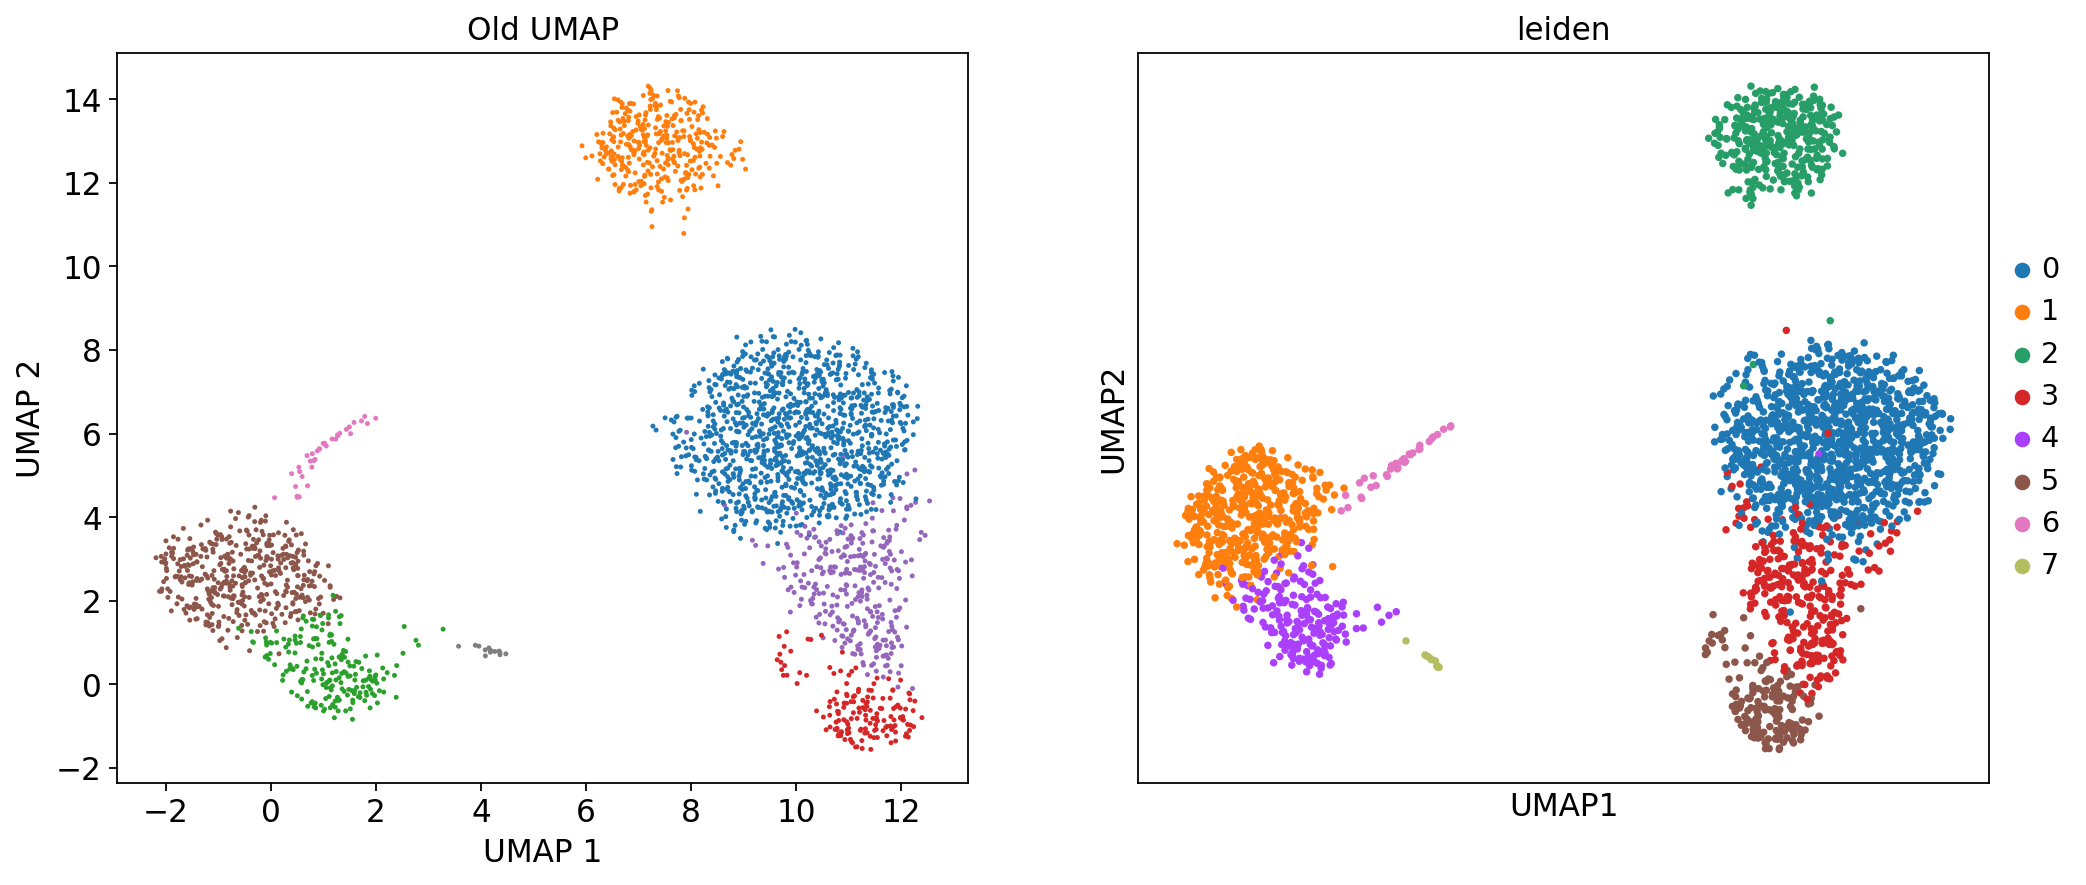

<Figure size 320x320 with 0 Axes>

In [117]:
# Compare the two UMAPS
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes = axes.flatten()

# Plot the old UMAP with matplotlib, remove grid
axes[0].scatter(adata.obsm['UMAP_old'][:, 0], adata.obsm['UMAP_old'][:, 1], c=colors, s=1.5)
axes[0].grid(False)
axes[0].set_title("Old UMAP")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

# Plot the new UMAP with scanpy
sc.pl.umap(adata, color="leiden", ax=axes[1])
axes[1].set_title("New UMAP")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()

In [119]:
# A potentially useful snippet
transformer.index_.query(adata.obsm['X_pca'], k=10, epsilon=0.1)

# If using transformer.fit
# distances.index_._neighbor_graph[0].shape

(array([[   0, 2014,  474, ...,   60,   35, 1864],
        [   1,  361,   10, ...,  272,  107, 2615],
        [   2, 1789, 1530, ..., 1434,   30, 1967],
        ...,
        [2635,  680, 1513, ..., 2269,  122, 1125],
        [2636, 1462,  966, ...,  280,  317, 2125],
        [2637, 1679,   15, ...,  693,  495,  214]], dtype=int32),
 array([[ 0.       , 10.702699 , 10.880815 , ..., 11.3667965, 11.481521 ,
         11.506379 ],
        [ 0.       , 12.16691  , 12.5824585, ..., 13.793109 , 13.895044 ,
         13.97666  ],
        [ 0.       , 11.09948  , 11.180496 , ..., 11.716736 , 11.753081 ,
         12.006598 ],
        ...,
        [ 0.       ,  9.498892 , 10.0179825, ..., 11.186194 , 11.223435 ,
         11.228255 ],
        [ 0.       , 14.105978 , 14.285706 , ..., 14.584891 , 14.843766 ,
         15.091596 ],
        [ 0.       ,  8.131726 ,  8.944085 , ...,  9.959799 ,  9.986422 ,
          9.998806 ]], dtype=float32))

## Extra: random things with NNDescent

This is the implementation used by the `nearest_neighbors` function of the `umap` package.

In [120]:
knn_search_index = NNDescent(
            adata.obsm['X_pca'],
            n_neighbors=10,
            metric="euclidean",
            metric_kwds=None,
            random_state=1,
            n_trees = min(64, 5 + int(round((adata.obsm['X_pca'].shape[0]) ** 0.5 / 20.0))),
            n_iters = max(5, int(round(np.log2(adata.obsm['X_pca'].shape[0])))),
            max_candidates=60,
            low_memory=True,
            n_jobs=-1,
            verbose=False,
            compressed=False,
)

In [85]:
knn_search_index.neighbor_graph

(array([[   0, 2014,  474, ...,   74,  970, 1148],
        [   1,  361,   10, ..., 1894, 1076, 1756],
        [   2, 1789, 1530, ..., 2006, 1414, 1883],
        ...,
        [2635,  680, 1513, ..., 2391, 1877, 2533],
        [2636, 1462,  966, ...,  442,  171,  235],
        [2637, 1679,   15, ...,   70,  225,   41]], dtype=int32),
 array([[ 0.       , 10.702699 , 10.880815 , ..., 13.567766 , 13.57224  ,
         13.574897 ],
        [ 0.       , 12.16691  , 12.5824585, ..., 18.043003 , 18.043373 ,
         18.044798 ],
        [ 0.       , 11.09948  , 11.180496 , ..., 13.90811  , 13.913291 ,
         13.914312 ],
        ...,
        [ 0.       ,  9.498892 , 10.0179825, ..., 14.346585 , 14.347189 ,
         14.355065 ],
        [ 0.       , 14.105978 , 14.285706 , ..., 19.193686 , 19.201513 ,
         19.209414 ],
        [ 0.       ,  8.131726 ,  8.944085 , ..., 11.94045  , 11.94721  ,
         11.949596 ]], dtype=float32))

In [121]:
from umap.umap_ import nearest_neighbors

tmp = nearest_neighbors(adata.obsm['X_pca'],
                              n_neighbors=10,
                              metric="euclidean",
                              metric_kwds=None,
                              angular=False,
                              random_state=1,
                             )

In [33]:
adata.write(results_file)